In [8]:
import os
from typing import Tuple
import numpy as np
import sunpy.map
import numpy as np
from skimage.transform import resize

# Lectura de imágenes 

In [9]:

def read_single_fits_image(file_path: str) -> Tuple[np.ndarray, dict]:

    """
    Load data and metadata from a single FITS file.

    Args:
        file_path (str): Absolute or relative path to the FITS file.

    Returns:
        Tuple[np.ndarray, dict]: A tuple containing the image data as a NumPy array
        and the associated metadata dictionary.

    Raises:
        FileNotFoundError: If the specified file does not exist.
        ValueError: If the file extension is not '.fits'.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"FITS file not found: {file_path}")
    
    if not file_path.endswith(".fits"):
        raise ValueError(f"Invalid file format: {file_path}. Expected a '.fits' file.")

    aia_map = sunpy.map.Map(file_path)
    return aia_map.data, aia_map.meta


def create_circular_mask(data: np.ndarray, metadata: dict) -> np.ndarray:
    """
    Creates a circular mask for the solar disk based on FITS metadata.

    Args:
        data (np.ndarray): 2D array of image data.
        metadata (dict): Dictionary containing FITS header metadata.

    Returns:
        np.ndarray: Boolean mask where True indicates pixels inside the solar disk.
    """
    ny, nx = data.shape
    x_center = metadata.get("crpix1", nx / 2) - 1  # FITS is 1-based
    y_center = metadata.get("crpix2", ny / 2) - 1
    cdelt1 = metadata.get("cdelt1", 1.0)  # arcsec/pixel
    solar_radius_arcsec = metadata.get("rsun_obs", 960.0)  # default value in arcsec

    solar_radius_pixels = abs(solar_radius_arcsec / cdelt1)

    y, x = np.ogrid[:ny, :nx]
    distance_from_center = np.sqrt((x - x_center)**2 + (y - y_center)**2)
    return distance_from_center <= solar_radius_pixels


def preprocess_image(
    data: np.ndarray, mask: np.ndarray, size: int = 512
) -> np.ndarray:
    """
    Resize the image and mask, and apply the mask by setting outside values to NaN.

    Args:
        data (np.ndarray): 2D image array.
        mask (np.ndarray): Boolean mask of the same shape as data.
        size (int): Output image size (square) in pixels. Default is 512.

    Returns:
        np.ndarray: Preprocessed image with masked-out areas as NaN.
    """
    resized_data = resize(
        data, (size, size), mode='reflect', anti_aliasing=True
    )
    resized_mask = resize(
        mask.astype(float), (size, size), mode='reflect', anti_aliasing=False
    ) > 0.5
    masked_data = resized_data.copy()
    masked_data[~resized_mask] = np.nan
    return masked_data



In [6]:
datos = read_single_fits_image(r"sdo_data\aia_94\aia.lev1_euv_12s.2019-03-31T235959Z.94.image.fits")

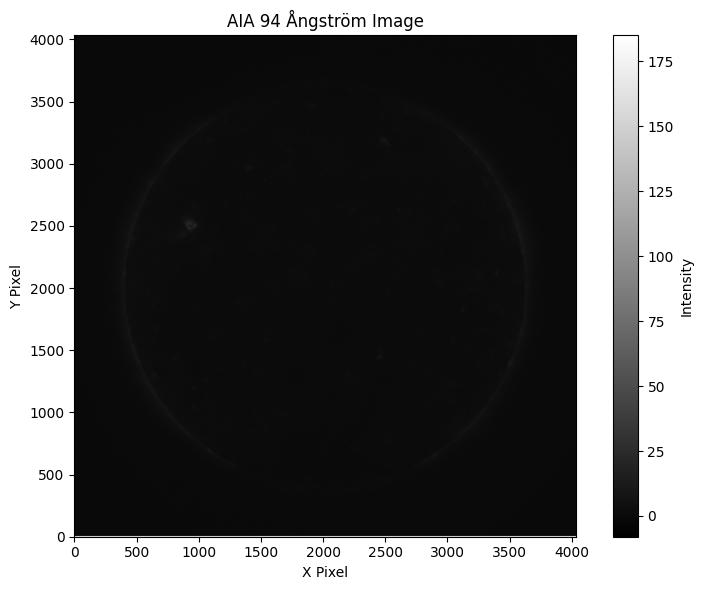

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def show_fits_image(data: np.ndarray, title: str = "FITS Image") -> None:
    """
    Display a FITS image using matplotlib.

    Args:
        data (np.ndarray): The image data to visualize.
        title (str): Title of the plot. Default is 'FITS Image'.

    Returns:
        None
    """
    plt.figure(figsize=(8, 6))
    plt.imshow(data, cmap='gray', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title(title)
    plt.xlabel('X Pixel')
    plt.ylabel('Y Pixel')
    plt.tight_layout()
    plt.show()


show_fits_image(datos[0], title="AIA 94 Ångström Image")